# Part 2: StyleGAN Latent Space Editing

## Introduction

### Beyond Generation: Editing in Latent Space
In the previous task, we built a GAN to generate images from random noise. State-of-the-art models like **StyleGAN** produce stunningly realistic images. More importantly, their **latent space** (a high-dimensional space where the input noise vectors live) is often highly structured and meaningful.

This means that specific directions in the latent space correspond to semantic attributes of the image, such as age, hair color, or expression. By finding these directions, we can perform realistic image editing without ever touching the image pixels directly.

### The Goal: Finding the "Smile" Vector
In this test, we will use a pre-trained StyleGAN2 model. Our goal is to find the direction vector in its `W` latent space that corresponds to **smiling**. We will achieve this by:

1.  Using a pre-labeled dataset of latent vectors (`w` vectors) and their corresponding smile labels.
2.  Training a simple linear classifier to distinguish between smiling and non-smiling latent vectors.
3.  Extracting the **weight** of this trained classifier. This weight itself is the direction vector we are looking for!
4.  Applying this direction vector to a new face's latent code to make it smile.

## Submission
This is the second part of the test. Your final score will be the sum of scores from both parts. Please submit this notebook along with the main test file.

> The total points for this part is **50**.

---

## Part 1: Setup and Loading Pre-trained Models
First, we'll load a pre-trained StyleGAN2 generator from PyTorch Hub and a pre-prepared dataset of latent vectors with smile labels.

In [1]:
!pip3 install torch torchvision matplotlib tqdm opencv-python requests
!git clone https://github.com/NVlabs/stylegan2-ada-pytorch.git
import sys
sys.path.append('./stylegan2-ada-pytorch')

  Using cached requests-2.32.4-py3-none-any.whl.metadata (4.9 kB)
  Using cached charset_normalizer-3.4.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (35 kB)
  Using cached idna-3.10-py3-none-any.whl.metadata (10 kB)
  Using cached urllib3-2.5.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached certifi-2025.6.15-py3-none-any.whl.metadata (2.4 kB)
Using cached requests-2.32.4-py3-none-any.whl (64 kB)
Using cached charset_normalizer-3.4.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (149 kB)
Using cached idna-3.10-py3-none-any.whl (70 kB)
Using cached urllib3-2.5.0-py3-none-any.whl (129 kB)
Using cached certifi-2025.6.15-py3-none-any.whl (157 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [requests]━━ 4/5 [requests]ormalizer]
Cloning into 'stylegan2-ada-pytorch'...
remote: Enumerating objects: 131, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 131 (delta 0), reused 0 (delta 0), pac

In [2]:
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import legacy
import dnnlib
import requests

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


### Load StyleGAN2 Generator
This will download the model, which may take a minute.

In [4]:
def download_file(url, local_path):
    os.makedirs(os.path.dirname(local_path), exist_ok=True)
    if os.path.exists(local_path):
        print(f"[✓] existing: {local_path}")
        return
    print(f"[↓] download {url}")
    response = requests.get(url, stream=True)
    with open(local_path, 'wb') as f:
        for chunk in tqdm(response.iter_content(chunk_size=8192)):
            f.write(chunk)

def download_stylegan2_ffhq():
    ckpt_url = "https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/ffhq.pkl"
    local_path = "checkpoints/stylegan2_ffhq.pkl"
    download_file(ckpt_url, local_path)
    return local_path

def load_stylegan2_generator(ckpt_path):
    with open(ckpt_path, 'rb') as f:
        G = legacy.load_network_pkl(f)['G_ema'].to(device)  # type: ignore
    G.eval()
    return G
ckpt_path = download_stylegan2_ffhq()
generator = load_stylegan2_generator(ckpt_path)
generator.eval()

[↓] download https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/ffhq.pkl


46585it [01:47, 435.27it/s] 


Generator(
  (synthesis): SynthesisNetwork(
    (b4): SynthesisBlock(
      (conv1): SynthesisLayer(
        (affine): FullyConnectedLayer()
      )
      (torgb): ToRGBLayer(
        (affine): FullyConnectedLayer()
      )
    )
    (b8): SynthesisBlock(
      (conv0): SynthesisLayer(
        (affine): FullyConnectedLayer()
      )
      (conv1): SynthesisLayer(
        (affine): FullyConnectedLayer()
      )
      (torgb): ToRGBLayer(
        (affine): FullyConnectedLayer()
      )
    )
    (b16): SynthesisBlock(
      (conv0): SynthesisLayer(
        (affine): FullyConnectedLayer()
      )
      (conv1): SynthesisLayer(
        (affine): FullyConnectedLayer()
      )
      (torgb): ToRGBLayer(
        (affine): FullyConnectedLayer()
      )
    )
    (b32): SynthesisBlock(
      (conv0): SynthesisLayer(
        (affine): FullyConnectedLayer()
      )
      (conv1): SynthesisLayer(
        (affine): FullyConnectedLayer()
      )
      (torgb): ToRGBLayer(
        (affine): FullyConn

### Load Pre-prepared Latent Data
To simplify this task, we provide a file `latent_labels.pt` containing 2000 latent vectors from StyleGAN's `W` space and their corresponding smile labels (1 for smile, 0 for no smile). We will use this data to train our classifier.

In [5]:
# Load the data
data = torch.load('latent_labels.pt')
latents = data['latents'] # Shape: [2000, 512]
labels = data['labels']   # Shape: [2000, 1]

print(f"Loaded {latents.shape[0]} latent vectors and labels.")

# Create a PyTorch Dataset and DataLoader
dataset = TensorDataset(latents, labels)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

Loaded 2000 latent vectors and labels.


/tmp/ipykernel_121165/1598137595.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load('latent_labels.pt')


## Q1: Training the Latent Space Classifier (20 pts)
Our first task is to train a very simple linear classifier. This classifier will learn to separate the latent vectors that produce smiling faces from those that don't.

### Q1.1 Define the Classifier (10 pts)
**Task:** Create a `nn.Module` for a linear classifier. It should consist of a single `nn.Linear` layer that takes a latent vector of size 512 and outputs a single logit.

In [6]:
class LatentClassifier(nn.Module):
    def __init__(self, latent_dim, output_dim=1):
        super(LatentClassifier, self).__init__()
        # Q1.1: Define a single linear layer that maps from latent_dim to output_dim
        self.fc = nn.Linear(latent_dim, output_dim)

    def forward(self, w):
        return self.fc(w)

# Instantiate the classifier
latent_dim = 512
classifier = LatentClassifier(latent_dim).to(device)

### Q1.2 Implement the Training Loop (10 pts)
**Task:** Implement a standard training loop for your classifier. Use `BCEWithLogitsLoss` as the criterion and an `Adam` optimizer.

In [7]:
def train_classifier(model, loader, num_epochs=40):
    model.train()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(num_epochs):
        running_loss = 0.0
        for latents_batch, labels_batch in loader:
            latents_batch = latents_batch.to(device)
            labels_batch = labels_batch.to(device)
            
            # Q1.2: Implement the training step (approx. 4 lines)
            # 1. Zero the gradients
            # 2. Get predictions from the model (forward pass)
            # 3. Calculate the loss
            # 4. Backpropagate and step the optimizer
            optimizer.zero_grad()
            predictions = model(latents_batch)
            loss = criterion(predictions, labels_batch)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
        
        avg_loss = running_loss / len(loader)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

print("Training the latent classifier...")
train_classifier(classifier, dataloader)

Training the latent classifier...
Epoch [1/40], Loss: 0.5323
Epoch [2/40], Loss: 0.4625
Epoch [3/40], Loss: 0.4478
Epoch [4/40], Loss: 0.4368
Epoch [5/40], Loss: 0.4228
Epoch [6/40], Loss: 0.4146
Epoch [7/40], Loss: 0.4071
Epoch [8/40], Loss: 0.4002
Epoch [9/40], Loss: 0.3956
Epoch [10/40], Loss: 0.3915
Epoch [11/40], Loss: 0.3848
Epoch [12/40], Loss: 0.3818
Epoch [13/40], Loss: 0.3755
Epoch [14/40], Loss: 0.3733
Epoch [15/40], Loss: 0.3717
Epoch [16/40], Loss: 0.3654
Epoch [17/40], Loss: 0.3621
Epoch [18/40], Loss: 0.3610
Epoch [19/40], Loss: 0.3572
Epoch [20/40], Loss: 0.3582
Epoch [21/40], Loss: 0.3514
Epoch [22/40], Loss: 0.3492
Epoch [23/40], Loss: 0.3470
Epoch [24/40], Loss: 0.3486
Epoch [25/40], Loss: 0.3439
Epoch [26/40], Loss: 0.3419
Epoch [27/40], Loss: 0.3421
Epoch [28/40], Loss: 0.3385
Epoch [29/40], Loss: 0.3387
Epoch [30/40], Loss: 0.3343
Epoch [31/40], Loss: 0.3351
Epoch [32/40], Loss: 0.3321
Epoch [33/40], Loss: 0.3294
Epoch [34/40], Loss: 0.3260
Epoch [35/40], Loss: 0.

## Q2: Finding and Applying the Edit Direction (25 pts)
Now that we have a trained classifier, we can extract the 'smile' direction and use it to edit faces.

### Q2.1 Extract the Direction Vector (10 pts)
The weight of our trained linear classifier represents the normal vector to the decision boundary it has learned. This vector points in the direction that maximally increases the output logit, which in our case, is the 'smile' direction.

**Task:** Extract the weight from the trained classifier. This will be our direction vector. It's good practice to normalize this vector.

In [8]:
def get_direction_vector(model):
    # Q2.1: Extract the weight from the model's linear layer.
    # Hint: access it via model.fc.weight
    # Use .detach() to remove it from the computation graph.
    direction = model.fc.weight.detach()
    
    # Normalize the direction vector to have a unit length
    direction_norm = direction / torch.norm(direction)
    return direction_norm

smile_direction = get_direction_vector(classifier)
print(f"Extracted 'smile' direction vector with shape: {smile_direction.shape}")

Extracted 'smile' direction vector with shape: torch.Size([1, 512])


### Q2.2 Latent Space Interpolation (15 pts)
To edit a face, we take its latent vector `w` and move it along our `smile_direction`. The formula is: `w_edited = w_start + strength * smile_direction`, where `strength` controls the intensity of the edit.

**Task:** Complete the function below to apply this formula for a range of different strengths and generate an image for each new latent vector.

In [9]:
def edit_image(g, w_start, direction, strengths):
    g.eval()
    edited_images = []

    with torch.no_grad():
        for strength in strengths:
            # Q2.2: Implement the editing logic (approx. 2-3 lines)
            # 1. Calculate the change to apply: strength * direction
            # 2. Add this change to the broadcasted w vector to get `w_edited`.
            # 3. Use the generator's `synthesis` network to generate an image from `w_edited`.
            delta = strength * direction
            w_edited = w_start + delta
            img = g.synthesis(w_edited, noise_mode='const')
            
            edited_images.append(img.cpu())
    
    return edited_images

## Q3: Final Visualization and Analysis (5 pts)
Let's see the result! This final block will use your `edit_image` function to generate a sequence of images, transforming a neutral face into a smiling one. Your score for this section depends on the successful execution of this block based on your previous code.

Setting up PyTorch plugin "bias_act_plugin"... Failed!


/mnt/slurm_home/tywei/workspace/workspace/IOAI_2025/./stylegan2-ada-pytorch/torch_utils/ops/bias_act.py:50: UserWarning: Failed to build CUDA kernels for bias_act. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/mnt/slurm_home/tywei/workspace/workspace/IOAI_2025/./stylegan2-ada-pytorch/torch_utils/ops/bias_act.py", line 48, in _init
    _plugin = custom_ops.get_plugin('bias_act_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/mnt/slurm_home/tywei/workspace/workspace/IOAI_2025/./stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 110, in get_plugin
    torch.utils.cpp_extension.load(name=module_name, verbose=verbose_build, sources=sources, **build_kwargs)
  File "/mnt/slurm_home/tywei/anaconda3/lib/python3.10/site-packages/torch/utils/cpp_extension.py", line 1312, in load
    return _jit_compile(
  File "/mnt/slurm_home/tywei/anaconda3/lib/python3.10/site-packages/torch/utils/cpp_extension.py", line 1722, i

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!


/mnt/slurm_home/tywei/workspace/workspace/IOAI_2025/./stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/mnt/slurm_home/tywei/workspace/workspace/IOAI_2025/./stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/mnt/slurm_home/tywei/workspace/workspace/IOAI_2025/./stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 110, in get_plugin
    torch.utils.cpp_extension.load(name=module_name, verbose=verbose_build, sources=sources, **build_kwargs)
  File "/mnt/slurm_home/tywei/anaconda3/lib/python3.10/site-packages/torch/utils/cpp_extension.py", line 1312, in load
    return _jit_compile(
  File "/mnt/slurm_home/tywei/anaconda3/lib/python3.10/site-packages/torch/utils/cpp_extension.py", line 172

Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... 

...

/mnt/slurm_home/tywei/workspace/workspace/IOAI_2025/./stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/mnt/slurm_home/tywei/workspace/workspace/IOAI_2025/./stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/mnt/slurm_home/tywei/workspace/workspace/IOAI_2025/./stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 110, in get_plugin
    torch.utils.cpp_extension.load(name=module_name, verbose=verbose_build, sources=sources, **build_kwargs)
  File "/mnt/slurm_home/tywei/anaconda3/lib/python3.10/site-packages/torch/utils/cpp_extension.py", line 1312, in load
    return _jit_compile(
  File "/mnt/slurm_home/tywei/anaconda3/lib/python3.10/site-packages/torch/utils/cpp_extension.py", line 174

Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... 

/mnt/slurm_home/tywei/workspace/workspace/IOAI_2025/./stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/mnt/slurm_home/tywei/workspace/workspace/IOAI_2025/./stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/mnt/slurm_home/tywei/workspace/workspace/IOAI_2025/./stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 110, in get_plugin
    torch.utils.cpp_extension.load(name=module_name, verbose=verbose_build, sources=sources, **build_kwargs)
  File "/mnt/slurm_home/tywei/anaconda3/lib/python3.10/site-packages/torch/utils/cpp_extension.py", line 1312, in load
    return _jit_compile(
  File "/mnt/slurm_home/tywei/anaconda3/lib/python3.10/site-packages/torch/utils/cpp_extension.py", line 174

Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Setting up PyTorch plugin "upfirdn2d_plugin"... Failed!
Image editing result:


/mnt/slurm_home/tywei/workspace/workspace/IOAI_2025/./stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py:34: UserWarning: Failed to build CUDA kernels for upfirdn2d. Falling back to slow reference implementation. Details:

Traceback (most recent call last):
  File "/mnt/slurm_home/tywei/workspace/workspace/IOAI_2025/./stylegan2-ada-pytorch/torch_utils/ops/upfirdn2d.py", line 32, in _init
    _plugin = custom_ops.get_plugin('upfirdn2d_plugin', sources=sources, extra_cuda_cflags=['--use_fast_math'])
  File "/mnt/slurm_home/tywei/workspace/workspace/IOAI_2025/./stylegan2-ada-pytorch/torch_utils/custom_ops.py", line 110, in get_plugin
    torch.utils.cpp_extension.load(name=module_name, verbose=verbose_build, sources=sources, **build_kwargs)
  File "/mnt/slurm_home/tywei/anaconda3/lib/python3.10/site-packages/torch/utils/cpp_extension.py", line 1312, in load
    return _jit_compile(
  File "/mnt/slurm_home/tywei/anaconda3/lib/python3.10/site-packages/torch/utils/cpp_extension.py", line 174

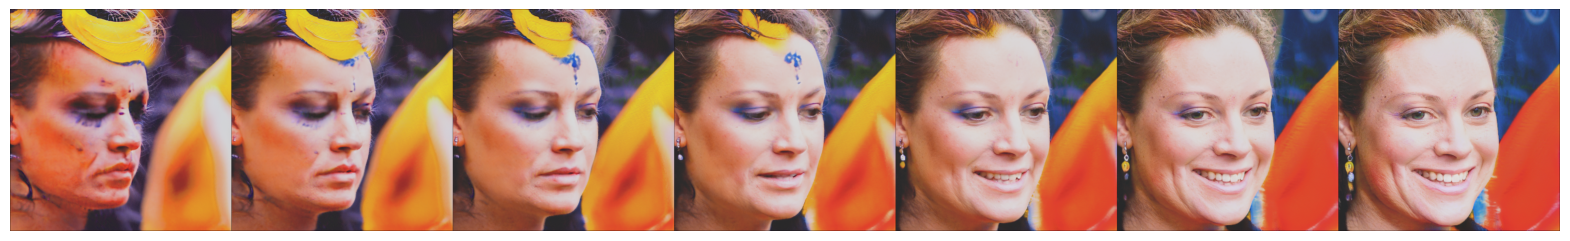


Analysis: As the strength increases from negative to positive, the facial expression smoothly transitions from a neutral or frowning look to a distinct smile, confirming that our learned vector indeed captures the 'smile' attribute.


In [ ]:
def show_image_strip(images):
    images = [img.squeeze(0).cpu() for img in images]
    grid = torchvision.utils.make_grid(images, nrow=len(images), normalize=True, padding=1)
    plt.figure(figsize=(20, 5))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis('off')
    plt.show()

# 1. Generate a random starting face
torch.manual_seed(123) # for reproducibility
noise = torch.randn(1, 512, device=device)
# Map the initial noise z to the intermediate latent space w
with torch.no_grad():
    w_start = generator.mapping(z=noise, c=None)

# 2. Define a range of edit strengths
strengths = np.linspace(-7, 7, 7) # from frown to big smile

# 3. Call your function to get the edited images
edited_strip = edit_image(generator, w_start, smile_direction, strengths)

# 4. Display the results
print("Image editing result:")
show_image_strip(edited_strip)


# Brief Analysis (Optional)
print("\nAnalysis: As the strength increases from negative to positive, the facial expression smoothly transitions from a neutral or frowning look to a distinct smile, confirming that our learned vector indeed captures the 'smile' attribute.")